In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
from scipy.special import roots_legendre, eval_legendre
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets
import discretize
import  os
import json
from PIL import Image
import seaborn as sns
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import ipywidgets as widgets
import string
eps = np.finfo(float).eps

In [2]:
import empymod
from masa_utils import PsuedoLog
from masa_utils import Pelton_res_f, DDR_f
from masa_utils import InducedPolarizationSimulation 
from masa_utils import Optimization 
from masa_utils import empymod_IP_simulation
from masa_utils import TEM_Signal_Process


Simulatin and synthetic study on deep sea hydrothermal deposits explortaion using WISTEM (K. Nakayama and A. Saito, 2016) (K.Nakayama M. Motoori and A. Saito,2019). On-Time: 200msec ramp time: 200usec Transmitter Loop: 3.5m Square Loop Receiver Loop: Coincident-type Number of Turn: 5 3.5m rectangular loop has equivalent area for 2.0m circular loop.

In [3]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


In [4]:
plt.style.use('00_figures.mplstyle')
textwidth = 5.60739

In [5]:

rmp_time=200e-6

smp_freq=50e3 #200e3  

In [6]:
tx_side = 3.5
tx_radius = (tx_side)/(np.sqrt(np.pi))
tx_circumeference = 2*np.pi*tx_radius
tx_surface = np.pi*tx_radius**2
n_turns = 5
tx_depth = 0
print(f"Transmitter radius: {tx_radius}")

Transmitter radius: 1.9746635424171473


In [7]:
tstrt, tend = 1e-4, 1e-2
logstep = 1/15
WISTEM_SP_sim = TEM_Signal_Process(
    # base_freq=base_freq,
    # on_time=on_time, 
    rmp_time=rmp_time, 
    rec_time=tend, 
    smp_freq=smp_freq
)


In [8]:
times_sim = WISTEM_SP_sim.times_rec
times_clc = WISTEM_SP_sim.times_rec
ntimes = len(times_clc)
print(ntimes)
print(times_clc[:3], times_clc[-3:])
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
windows_strt = WISTEM_SP_sim.windows_strt
windows_cen = WISTEM_SP_sim.windows_cen
windows_end = WISTEM_SP_sim.windows_end
print(windows_cen-rmp_time)

500
[2.e-05 4.e-05 6.e-05] [0.00996 0.00998 0.01   ]
[0.0001     0.00011659 0.00013594 0.00015849 0.00018478 0.00021544
 0.00025119 0.00029286 0.00034145 0.00039811 0.00046416 0.00054117
 0.00063096 0.00073564 0.0008577  0.001      0.00116591 0.00135936
 0.00158489 0.00184785 0.00215443 0.00251189 0.00292864 0.00341455
 0.00398107 0.00464159 0.0054117  0.00630957 0.00735642 0.00857696]


In [9]:
nlayer =1
nmodel = 3
rho0_targets = np.r_[0.3 , 0.3 , 0.3 ]
eta_targets = np.r_[0.2, 0.2, 0.20 ]
# eta_targets = np.r_[0.4, 0.4, 0.40 ]
eta_sea , eta_base = 0.,0.
c_targets = np.r_[0.6, 0.6, 0.6] 
thick_target = 10.
# tau_targets = np.r_[0.001, 0.01, 0.1]
# tau_targets = np.r_[0.001, 0.003, 0.01]
tau_targets = np.r_[0.0003, 0.001, 0.01]

res_sea = 0.3
res_base = 1.0
tau_seas, tau_bases  = tau_targets, tau_targets
c_seas, c_bases,  = c_targets, c_targets
tx_heights = 1.0*np.ones(nmodel) #np.r_[0.3,0.3,0.3] #csx
depths = []
for tx_height in tx_heights:
    depth = np.r_[0,  thick_target]
    depth += tx_height
    depths.append(depth)
print(f"depths {depths}")

print(tx_heights)

depths [array([ 1., 11.]), array([ 1., 11.]), array([ 1., 11.])]
[1. 1. 1.]


In [10]:
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
filt_linrmp = WISTEM_SP_sim.filter_linear_rmp()

Window_mat = WISTEM_SP_sim.get_window_matrix(times_sim)
print(Window_mat.shape)

(30, 500)


In [11]:
recx, recy = 0 , 0
recBdple = [recx, recy, tx_depth ,0,90]
# recx, recy, recw = rec_area(3, tx_side)
# recBdple = [recx, recy, tx_depth ,0,90]

In [12]:

empymod_model_sims = []
for i in range(nmodel):
    depth = depths[i]
    empymod_model_sim = {
        # simulate each bipole of four side of the transmitter loop
        'src': [ tx_side/2, tx_side/2,  # x1,x2
                        0, tx_side/2,  # y1,y2
                tx_depth, tx_depth], # z1,z2
        # receiver at the center of the transmitter loop
        'rec': recBdple, # [recx, recy, tx_depth ,0,90], # dBzdt at x,y,z,azimuth,dip
        'depth': depth,
    #    'res' : res,
        'freqtime': times_sim,
        'signal': None, # 0, # 0: impulse or dBdt, 1: Stepoff or B field
        'msrc' : False, # Electric source
        'mrec' : True, # Magnetic receiver
        'strength': 8.*n_turns* tx_surface * mu_0,  
        'srcpts' : 3,  # Three works for the momtent, maybe worth seeking other number
        'verb': 0, # put 4 for more information
        # Setting xdirect=True can help, as direct field is then computed analytically in f-domain
        'xdirect': True,
    }
    empymod_model_sims.append(empymod_model_sim)

In [13]:

m_trues = []
m_refs = []
sim_obs_cmb = []
for i in range(nmodel):
    rho0_target, eta_target = rho0_targets[i], eta_targets[i]
    tau_target, c_target = tau_targets[i], c_targets[i]
    empymod_model_sim = empymod_model_sims[i]

    m_true  = np.r_[np.log(rho0_target), eta_target, np.log(tau_target), c_target]
    m_trues.append(m_true)

    # emoymod model to simulate WISTEM setting
    # Note that it simulate only dBdt field at center of the transmitter loop
    # User should multiply by area of the loop to get EMF(V/A)


    sim_obs=empymod_IP_simulation(ip_model='pelton',
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        times=times_sim, smp_freq=smp_freq
        )
    sim_obs.deepsea_signle_layer(
        res_sea=res_sea, res_base=res_base,
        eta_sea=eta_sea, eta_base=eta_base,
        tau_sea=tau_target, tau_base=tau_target, 
        c_sea=c_target, c_base=c_target
        )
    sim_obs_cmb.append(sim_obs)



In [14]:
for i in range(nmodel):
    sim_obs = sim_obs_cmb[i]
    mvec_obs = m_trues[i]
    sim_obs.cut_off = None
    sim_obs.filt_curr = None
    sim_obs.window_mat= None
    dpred_step= sim_obs.dpred(mvec_obs)
    sim_obs.cut_off = smp_freq/2.0
    print(f"cutoff frequency: {sim_obs.cut_off}")
    dpred_LPF = sim_obs.dpred(mvec_obs)
    sim_obs.filt_curr = filt_linrmp
    dpred_rmp = sim_obs.dpred(mvec_obs)
    sim_obs.window_mat=Window_mat
    dpred_window = sim_obs.dpred(mvec_obs)

cutoff frequency: 25000.0
cutoff frequency: 25000.0
cutoff frequency: 25000.0


In [15]:
m_ref = np.r_[np.log(res_sea), 0, np.log(tau_seas[0]), c_seas[0]]
dpred_ref = sim_obs.dpred(m_ref)

In [16]:
PL_decay = PsuedoLog(
    logmin=1e-8,
    linScale=0.5,
    logminx=1e-4,
    linScalex=0.2
    )
PL_filt = PsuedoLog(
    logmin=1e-7,
    linScale=0.2,
    logminx=1e-4,
    linScalex=0.2
    )
PL_jac = PsuedoLog(
    logmin=1e-1,
    linScale=0.5,
    logminx=1e-4,
    linScalex=0.2
    )


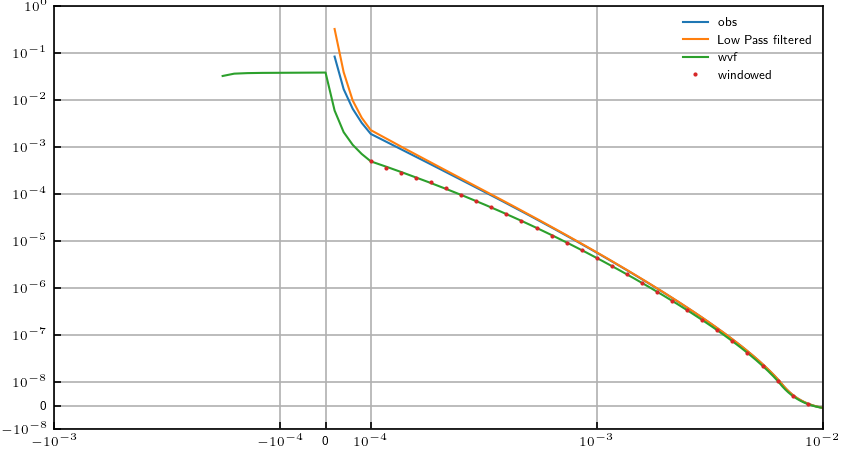

In [17]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3.0))

ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax=PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
ax.legend()


In [18]:
relative_error=0.05
data_noise_floor = 0.1e-7

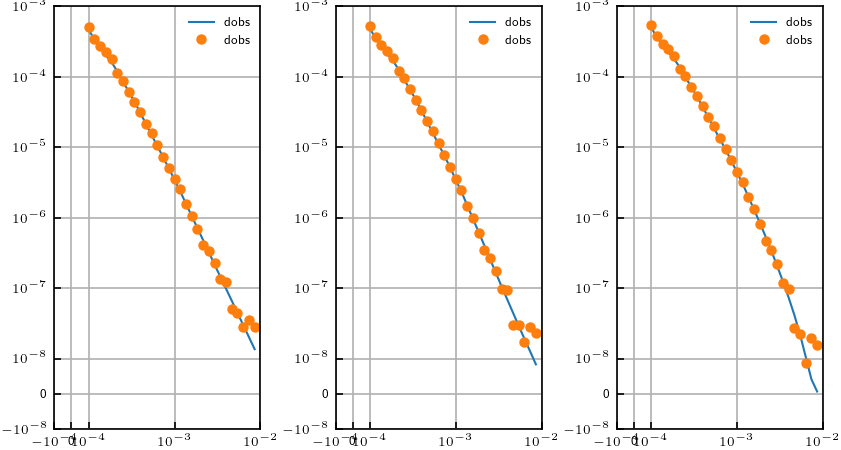

In [19]:
fig, ax= plt.subplots(1,3, figsize=(textwidth,3))
dobs_cmb =[]
ax= ax.flatten()
 # For reproducibility
for i in range(nmodel):
   sim_obs = sim_obs_cmb[i]
   mvec_obs = m_trues[i]
   # np.random.seed(i) # if you wanto have different noise for each model 
    # if you want the same noise for each model
   np.random.seed(0)
   # Calculate noise floor and relative erro at each window
   mvec_obs = m_trues[i]
   dobs_clean=sim_obs.dpred(mvec_obs)
   noise_floor = data_noise_floor
   noise_relative = relative_error * np.abs(dobs_clean)

   # Combine the two sources of noise
   total_noise = np.sqrt(noise_floor**2 + noise_relative**2)

   # Add the combined noise to the clean data
   dobs = dobs_clean +  np.random.randn(len(dobs_clean)) * total_noise

   dobs_cmb.append(dobs)
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs_clean, 
      label="dobs", color="C0", linestyle="-",ax=ax[i]
   )
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
      label="dobs", color="C1", marker="o",markersize=4,linestyle="",ax=ax[i]
   )
   ax[i]= PL_decay.pl_axes(ax[i])
   ax[i]= PL_decay.pl_axes_x(ax[i])

   ax[i].legend()


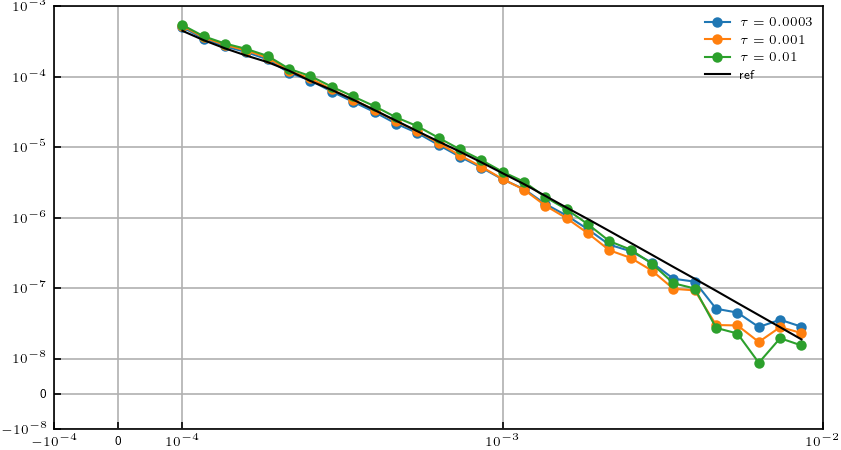

In [20]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3))

for i in range(nmodel):
   dobs = dobs_cmb[i]
   tau_target = tau_targets[i]
   label= fr'$\tau={tau_target}$'
   ax=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
      label=label, color=f"C{i}", marker="o",markersize=4,ax=ax
   )
ax =PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dpred_ref, 
      label="ref", color="k", linestyle="-",ax=ax
   )
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
ax.legend()


# Invert with Debye Decomposition model

In [21]:

taus_strt_log = -4.0*np.ones(nmodel) # np.r_[-3.25, -3.25, -3.25]
# taus_strt_log = np.r_[-4.0, -4.0, -4.0]
# taus_end_log  = np.r_[-2.00, -1.75, -1.50]
taus_end_log  = -2.00*np.ones(nmodel) #np.r_[-2.25, -2.25, -2.25]
taus_end = 10**taus_end_log
taus_strt = 10**taus_strt_log
print(taus_end)
print(taus_strt)
taus_step_log = 0.25

taus_max, taus_min = taus_end_log.max(), taus_strt_log.min()


[0.01 0.01 0.01]
[0.0001 0.0001 0.0001]


In [22]:

taus_cmb = []
m_refs = []
taus_colors = []
sim_inv = []
Wd_refs = []
J_refs = []
ntau_cmb= []
bool_etas_cmb = []
for i in range(nmodel):

    ntau =  int((taus_end_log[i] - taus_strt_log[i])/taus_step_log) +1
    taus= np.logspace(taus_strt_log[i], taus_end_log[i], ntau, endpoint=True)

    taus_color = (np.linspace(taus_strt_log[i], taus_end_log[i], ntau)-taus_min)/ (taus_max-taus_min)
    m_ref = np.r_[np.log(res_sea), np.zeros(ntau)]
    print(taus) 
    print(taus_color)
    taus_cmb.append(taus)
    ntau_cmb.append(ntau)
    taus_colors.append(taus_color)
    m_refs.append(m_ref)
    empymod_model_sim = empymod_model_sims[i]
    sim=empymod_IP_simulation(ip_model='DDR',chgmin=0,
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        taus=taus, times=times_sim, smp_freq=smp_freq
    )
    bool_etas = np.full(ntau, True)
    bool_etas_cmb.append(bool_etas)

    sim.deepsea_three_layers_bottom_fixed(
        bool_etas=bool_etas,
        res_sea=res_sea, res_base=res_base, eta_sea=eta_sea, eta_base=eta_base  
        )
    dpred_step= sim.dpred(m_ref)
    sim.cut_off = smp_freq/2.0
    dpred_LPF = sim.dpred(m_ref)
    sim.filt_curr = filt_linrmp
    dpred_rmp = sim.dpred(m_ref)
    sim.window_mat=Window_mat
    dpred_window = sim.dpred(m_ref)
    sim_inv.append(sim) 
    opt = Optimization(sim=sim_inv[i], dobs=dpred_window)
    opt.get_Wd(ratio=relative_error, plateau=data_noise_floor )
    Wd_refs.append(opt.Wd)
    J_refs.append(sim_inv[i].J(m_ref))
Wd_ref = Wd_refs[0]
ntau_max = max(ntau_cmb)

[0.0001     0.00017783 0.00031623 0.00056234 0.001      0.00177828
 0.00316228 0.00562341 0.01      ]
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
[0.0001     0.00017783 0.00031623 0.00056234 0.001      0.00177828
 0.00316228 0.00562341 0.01      ]
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
[0.0001     0.00017783 0.00031623 0.00056234 0.001      0.00177828
 0.00316228 0.00562341 0.01      ]
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


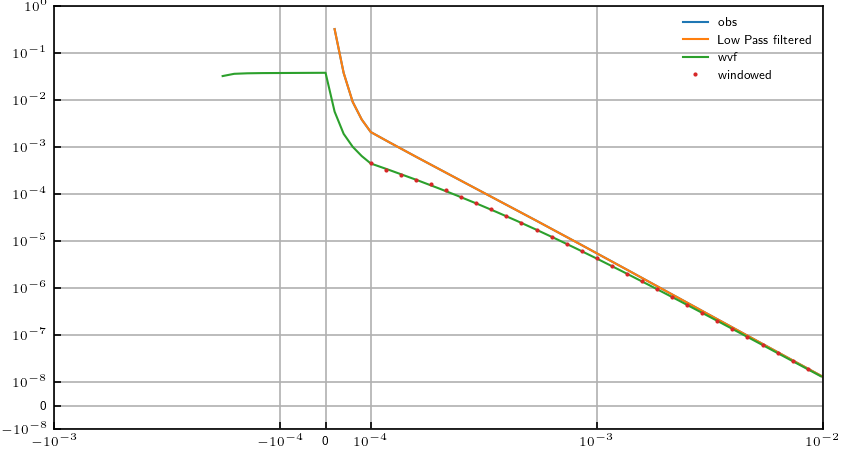

In [23]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3))

ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax=PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
#for ax in ax:
ax.legend()


In [24]:
colormap = plt.get_cmap("cool")

In [25]:
def plot_data(data_init, dpred, dobs,ax=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
       
    ax=PL_decay.semiply(windows_cen-rmp_time, data_init, ax=ax,
                       color="C1",label="ref" #
                       )
    ax=PL_decay.semiply(windows_cen-rmp_time, dpred, ax=ax
                        ,color="C0",linestyle="-",
                        label=f"est"# mated, iter={iteration}"
                        )
    ax=PL_decay.semiply(windows_cen-rmp_time, dobs, ax=ax, marker=".",markersize=2.0,
                       color="C3",linestyle="", label="obs"
                       )
    ax = PL_decay.pl_axes(ax)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")


    return ax

In [26]:
def plot_jacobian(irange, bool_etas=None,ax=None,max_y=None, min_y=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
    taus = taus_cmb[irange]
    taus_color = taus_colors[irange]
    ntau = ntau_cmb[irange]
    if bool_etas is None:
        bool_etas = np.full(ntau, True)
    J_ref = J_refs[irange]
    Wd_ref = Wd_refs[irange]
    rho0 = Wd_ref@J_ref[:,0]
    windows_maxrho0 = windows_cen[np.argmax(np.abs(rho0))]
    # ind = windows_cen >= windows_cen[np.argmax(np.abs(rho0))]
    for j in range(ntau):
        color = colormap(taus_color[j])
        linewidth = 1
        linestyle ='-'
        label = rf"$\Delta\eta_{{{j+1}}}, \tau_{{{j+1}}}: {sci_latex(taus[j], prec=1)}$"
        y = Wd_ref @ J_ref[:, j + nlayer]
        ax = PL_jac.semiply(
            x=windows_cen - rmp_time,
            y=y,
            color=color,
            linestyle=linestyle,
            label=label,
            linewidth=linewidth,
            ax=ax
        )

    for j in range(ntau):
        if bool_etas[j]: # only plot the jacobian for the parameters that are being inverted
            color = colormap(taus_color[j])
            linestyle =''
            marker = "."
            markersize = 2
            y = Wd_ref @ J_ref[:, j + nlayer]
            ax = PL_jac.semiply(
                x=windows_cen - rmp_time,
                y=y,
                color=color,
                linestyle=linestyle,
                marker=marker,
                markersize=markersize,
                ax=ax
            )

    ax=PL_jac.semiply(
        windows_cen-rmp_time,rho0,color="k",label=r"+$\Delta\rho_0$",ax=ax,
            linestyle="--", linewidth=1#, marker="o",markersize=4
            )

    ax=PL_jac.semiply(
        windows_cen-rmp_time, -rho0,color="k",label=r"-$\Delta\rho_0$",ax=ax,
            linestyle="-.", linewidth=1#, marker="o",markersize=4
            )
    ax.axvline(x=windows_maxrho0-rmp_time,  color="k", linestyle=":", label=r"peak of $-\Delta\rho_0$")
    ax= PL_jac.pl_axes(ax, max_y=max_y, min_y=min_y)
    ax.set_xlabel("Time (s)")
    ax.set_title(fr"$W_dJ$ for model_{irange+1}")
    return ax

In [27]:
def plot_taus(irange,bool_etas=None,ax=None):
    if ax is None:
        fig , ax = plt.subplots(1,1, figsize=(5,3))

    taus = taus_cmb[irange]
    taus_color = taus_colors[irange]
    ntau = ntau_cmb[irange]
    if bool_etas is None:
        bool_etas = np.full(ntau, True)
    ax.semilogx(taus, irange*np.ones_like(taus), color="k")
    marker= 'o'
    markersize = 2.0

    for j in range(ntau):

        if bool_etas[j]: # only plot the taus for the parameters that are being inverted
            color = colormap(taus_color[j])
            ax.semilogx(taus[j], irange, 
                linestyle="", color=color, marker=marker, markersize=markersize)
    ax.set_yticks(np.arange(0, nmodel))
    ax.set_yticklabels([fr"model_{i+1}" for i in range(nmodel)])
    ax.invert_yaxis()
    ax.set_title(r"$\tau_k$ for each model")
    ax.set_xlabel(r"$\tau_k$ (s)")
    return ax

In [28]:
bool_etas_cmb = []
for i in range(nmodel):
    sim = sim_inv[i]
    bool_etas = sim.activate_etas(WdJ=Wd_refs[i]@J_refs[i])
    bool_etas_cmb.append(bool_etas)


In [29]:
bool_etas_cmb

[array([False, False,  True,  True,  True,  True,  True, False, False]),
 array([False, False,  True,  True,  True,  True,  True, False, False]),
 array([False, False,  True,  True,  True,  True,  True, False, False])]

In [30]:
colormap = plt.get_cmap("turbo")

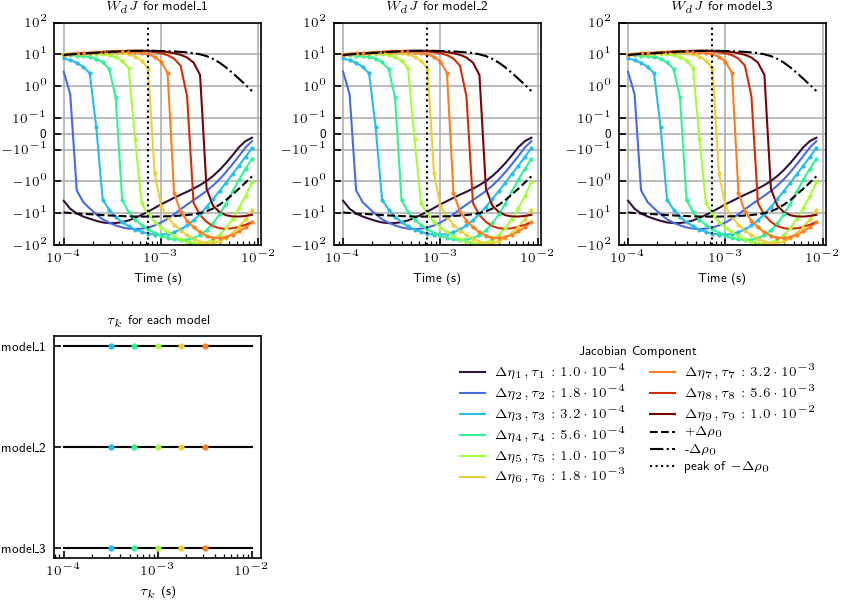

In [31]:
fig = plt.figure(figsize=(textwidth, 4))
gs = fig.add_gridspec(2, 3) 
ax_jacobians = []
for i in range(nmodel): 
    ax_jacobians.append(fig.add_subplot(gs[0,i ]))
ax_tau = fig.add_subplot(gs[1, 0])
ax_color = fig.add_subplot(gs[1, 1:])

for i in range(nmodel):
    bool_etas = bool_etas_cmb[i]
    ax_jacobian = ax_jacobians[i]
    ax_jacobian = plot_jacobian(
        irange=i, bool_etas=bool_etas, ax=ax_jacobian,
        )
    ax_tau=plot_taus(irange=i, bool_etas=bool_etas, ax=ax_tau)

# # ax_tau.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=1)

ax_tau.grid()

ax_jacobian = ax_jacobians[0]
handles, labels = ax_jacobian.get_legend_handles_labels()
ax_color.axis('off')
ax_color.legend(
    handles, labels, title="Jacobian Component",loc="upper right",
    ncol=2)

plt.savefig('../figures/46_DD_TEM_Jacobian.png')
plt.savefig('../manuscript/figures/46_DD_TEM_Jacobian.pdf')

In [32]:
# Reset simulation
m_refs = []
sim_inv = []

taus_act_cmb = []
taus_act_end_log = []
taus_act_strt_log = []

for i in range(nmodel):
    taus = taus_cmb[i]
    tx_height = tx_heights[i]
    empymod_model_sim = empymod_model_sims[i]
    sim=empymod_IP_simulation(ip_model='DDR',chgmin=0,
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        taus=taus, times=times_sim, smp_freq=smp_freq
    )
    bool_etas = bool_etas_cmb[i]

    sim.deepsea_three_layers_bottom_fixed(
        bool_etas=bool_etas,
        res_sea=res_sea, res_base=res_base, eta_sea=eta_sea, eta_base=eta_base  
        )
    taus_act = taus[bool_etas]
    taus_act_cmb.append(taus_act)
    taus_act_end_log.append(np.log10(taus_act.max()))
    taus_act_strt_log.append(np.log10(taus_act.min()))
    m_ref = np.r_[np.log(res_sea), np.zeros(len(taus_act))]
    m_refs.append(m_ref)

    sim.cut_off = smp_freq/2.0
    sim.filt_curr = filt_linrmp
    sim.window_mat=Window_mat
    sim_inv.append(sim) 



In [33]:
taus_act

array([0.00031623, 0.00056234, 0.001     , 0.00177828, 0.00316228])

# Inversion: Single layer fixed thickness

In [34]:
niter = 50
stol=1e-6
coolingFactor =2 # np.sqrt(2) #2.0
coolingRate = 2
mu=1e-3
beta0_ratio = 1.0
alphas= 1.0
Ws_threshold=1e-3

In [35]:
models_rec = []
dpreds = []
error_prgs = []
model_prgs = []
dinit_refs = []
data_prgs =[]
betas_prgs = []
for i in range(nmodel):
    m_ref = m_refs[i]
    sim = sim_inv[i]
    dobs= dobs_cmb[i]
    opt = Optimization(sim=sim, dobs=dobs, alphas=alphas, Ws_threshold=Ws_threshold)
    opt.get_Wd(ratio=relative_error, plateau=data_noise_floor )
    opt.get_Ws(smallness=np.ones(len(m_ref)))
    beta0 = opt.BetaEstimate_byEig(
        mvec=m_ref, update_Wsen=True, beta0_ratio=beta0_ratio)
    print(beta0)
    mpred = opt.GaussNewton(
    mvec_init=m_ref,niter=niter,beta0=beta0, update_Wsen=True,
    stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
    )
    
    dinit_refs.append(opt.dpred(m_ref))
    models_rec.append(mpred)
    dpreds.append(opt.dpred(mpred))
    error_prgs.append(opt.error_prg)
    model_prgs.append(opt.mvec_prg)
    data_prgs.append(opt.data_prg)
    betas_prgs.append(opt.betas)


3861883.370908678
  1, beta:3.9e+06, step:1.0e+00, g:8.5e+03, phid:3.7e+02, phim:3.5e-06, f:3.8e+02 
  2, beta:3.9e+06, step:1.0e+00, g:7.6e+01, phid:3.7e+02, phim:3.5e-06, f:3.8e+02 
  3, beta:1.9e+06, step:1.0e+00, g:4.0e+03, phid:3.2e+02, phim:1.2e-05, f:3.4e+02 
  4, beta:1.9e+06, step:1.0e+00, g:6.1e+01, phid:3.2e+02, phim:1.2e-05, f:3.4e+02 
  5, beta:9.7e+05, step:1.0e+00, g:3.7e+03, phid:2.5e+02, phim:3.7e-05, f:2.9e+02 
  6, beta:9.7e+05, step:1.0e+00, g:8.7e+01, phid:2.5e+02, phim:3.8e-05, f:2.9e+02 
  7, beta:4.8e+05, step:1.0e+00, g:3.3e+03, phid:1.7e+02, phim:9.6e-05, f:2.2e+02 
  8, beta:4.8e+05, step:1.0e+00, g:9.9e+01, phid:1.7e+02, phim:9.6e-05, f:2.2e+02 
  9, beta:2.4e+05, step:1.0e+00, g:2.6e+03, phid:1.1e+02, phim:1.9e-04, f:1.5e+02 
 10, beta:2.4e+05, step:1.0e+00, g:8.3e+01, phid:1.1e+02, phim:1.9e-04, f:1.5e+02 
 11, beta:1.2e+05, step:1.0e+00, g:1.9e+03, phid:6.5e+01, phim:3.1e-04, f:1.0e+02 
 12, beta:1.2e+05, step:1.0e+00, g:5.0e+01, phid:6.4e+01, phim:3.1e-0

In [36]:
phid_star=len(windows_cen)
models_rec_phid = []
dpreds_phid = []
phid_star_ratio =1.1
phid_itrs = []
chis = []
for i in range(nmodel):
    model_prg= np.array(model_prgs[i])
    data_prg = np.array(data_prgs[i])
    error_prg = error_prgs[i]
    phid_prg = np.array(error_prg)[:,1]
    ind = phid_prg < phid_star*phid_star_ratio
    if np.sum(ind) == 0:
        print(f" range {i}:No phid star found, take min phid")
        ind = phid_prg == np.min(phid_prg)
    phid = phid_prg[ind][0]
    phid_itr = np.where(ind)[0][0]
    models_rec_phid.append(model_prg[ind][0])
    dpreds_phid.append(data_prg[ind][0])
    phid_itrs.append(phid_itr)
    print(f"{phid/phid_star:.2f} of phid star at iteration {phid_itr}") 
    chis.append(phid/phid_star)

 range 0:No phid star found, take min phid
1.18 of phid star at iteration 26
 range 1:No phid star found, take min phid
1.10 of phid star at iteration 50
1.08 of phid star at iteration 19


In [37]:
chis

[np.float64(1.1836870776776227),
 np.float64(1.1008258723181532),
 np.float64(1.0776831334636026)]

In [38]:
print( "Parameter:  $\\rho_0$, $\\eta$, $\\tau_max$")
np_mvec_refs= []
np_mvec_ests= []
for i in range(nmodel):
    np_mvec_ref = m_refs[i]
    # mvec_est = models_rec[i]
    mvec_est = models_rec_phid[i]
    taus_max = taus_cmb[i].max()
    np_mvec_refs.append(np_mvec_ref)
    np_mvec_ests.append(mvec_est)
    # print(f"ref{i+1}     & {np.exp(np_mvec_ref[0]):.2e} & {np_mvec_ref[1:].sum():.3f} ")
    # print(f"est{i+1}     & {np.exp(np_mvec_est[0]):.2e} & { np_mvec_est[1:].sum():.3f} & {taus_max:.2e}")
    print(f"est_phid{i+1}& {np.exp(mvec_est[0]):.2e} & {mvec_est[1:].sum():.3f} ")


Parameter:  $\rho_0$, $\eta$, $\tau_max$
est_phid1& 3.04e-01 & 0.094 
est_phid2& 2.86e-01 & 0.129 
est_phid3& 2.60e-01 & 0.081 


Text(0, 0.5, 'EMF (V/A)')

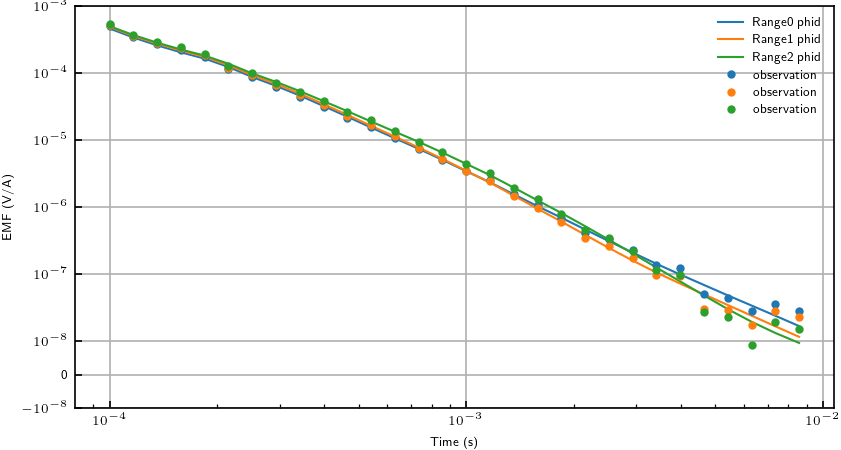

In [39]:
fig, ax= plt.subplots(1,1, figsize=(textwidth, 3))
for i in range(nmodel):
    ax = PL_decay.semiply(
        windows_cen-rmp_time, dpreds_phid[i], ax=ax,
        color=f"C{i}",linestyle="-", label=f"Range{i} phid"
        )
for i in range(nmodel):
    dobs = dobs_cmb[i]
    ax=PL_decay.semiply(
        windows_cen-rmp_time, dobs, ax=ax, marker="o",markersize=3.0,
        color=f"C{i}",linestyle="", label="observation"
        )
ax = PL_decay.pl_axes(ax)
ax.legend()
ax.set_xlabel("Time (s)")
ax.set_ylabel("EMF (V/A)")


# get SIP of target layer

In [40]:
freq_step_log  = 0.1
freq_cmb = []
freq_mins = []
freq_maxs = []
for i in range(nmodel):


    nfreq = int((taus_act_end_log[i] - taus_act_strt_log[i])/freq_step_log) +1
    freq = np.logspace(
        -taus_act_end_log[i], -taus_act_strt_log[i], nfreq, endpoint=True
        ) 
    # freq = 10**np.arange(-taus_end_log[i], -taus_strt_log[i]+freq_step_log, freq_step_log)
    freq /= 2.0*np.pi
    freq_cmb.append(freq)
    freq_mins.append(freq.min())
    freq_maxs.append(freq.max())
    print(f"Range {i}: nfreq {nfreq}, freq min {freq.min():.2e}, max {freq.max():.2e}")


Range 0: nfreq 11, freq min 5.03e+01, max 5.03e+02
Range 1: nfreq 11, freq min 5.03e+01, max 5.03e+02
Range 2: nfreq 11, freq min 5.03e+01, max 5.03e+02


In [41]:
freq_ext_strt_log= 1.0
freq_ext_end_log = 4.0

freq_ext = np.logspace(
    start=freq_ext_strt_log,
    stop=freq_ext_end_log,
    num= int((freq_ext_end_log-freq_ext_strt_log)/freq_step_log)+1,
    endpoint=True
    )
IP_model = Pelton_res_f(freq=freq_ext)



In [42]:
freq_ext

array([   10.        ,    12.58925412,    15.84893192,    19.95262315,
          25.11886432,    31.6227766 ,    39.81071706,    50.11872336,
          63.09573445,    79.43282347,   100.        ,   125.89254118,
         158.48931925,   199.5262315 ,   251.18864315,   316.22776602,
         398.10717055,   501.18723363,   630.95734448,   794.32823472,
        1000.        ,  1258.92541179,  1584.89319246,  1995.26231497,
        2511.88643151,  3162.27766017,  3981.07170553,  5011.87233627,
        6309.5734448 ,  7943.28234724, 10000.        ])

In [43]:
noise_floor_ratio = 1e-2
niter = 100
stol=1e-6
coolingFactor = 2 # np.sqrt(2) 
coolingRate = 2
mu=1e-3
beta0_ratio = 1.0

In [44]:
sip_trues =[]
sim_sip_dd = []
sim_sip_dd_ext = []
sim_sip_pel = []
sim_sip_pel_ext = []
sip_dpreds = []
model_recs_sip = []
dpreds_sip = []
error_prgs_sip = []
model_prgs_sip = []
dinit_refs_sip = []
data_prgs_sip =[]
betas_prgs_sip = []
tem_inv_taus = []


for i in range(nmodel):
    freq = freq_cmb[i]
    nfreq = len(freq)
    mvec_obs= m_trues[i]
    mvec_est = models_rec_phid[i]
    IP_model = Pelton_res_f(freq=freq)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_pel.append(sim)
    dobs_sip = sim.dpred(m=mvec_obs)
    sip_trues.append(dobs_sip)
    f_abs = abs(IP_model.f(mvec_obs))

    IP_model = Pelton_res_f(freq=freq_ext)
    sim_sip = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_pel_ext.append(sim_sip)

    taus_act = taus_act_cmb[i]

    IP_model = DDR_f(freq=freq_ext,taus=taus_act)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_dd_ext.append(sim)

    IP_model = DDR_f(freq=freq,taus=taus_act)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_dd.append(sim)

    sip_dpreds.append(sim.dpred(mvec_est))
    tau_mean = IP_model.mean_log_tau(mvec_est)
    tem_inv_taus.append(tau_mean)

    if nfreq > 1:
        noise_floor= f_abs.max()*noise_floor_ratio
        mvec_ref = m_refs[i]
        opt = Optimization(sim=sim, dobs= dobs_sip)
        opt.get_Wd(ratio=relative_error, plateau=noise_floor)
        opt.get_Ws(np.ones(len(mvec_ref)))
        beta0 = opt.BetaEstimate_byEig(mvec=mvec_ref, update_Wsen=True)
        mpred = opt.GaussNewton(
            mvec_init=mvec_ref,niter=niter,beta0=beta0, update_Wsen=True,
            stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
            )
        dinit_refs_sip.append(opt.dpred(mvec_ref))
        error_prgs_sip.append(opt.error_prg)
        model_prgs_sip.append(opt.mvec_prg)
        data_prgs_sip.append(opt.data_prg)
        betas_prgs_sip.append(opt.betas)
        model_recs_sip.append(mpred)
        dpreds_sip.append(opt.dpred(mpred))
    else:
        mpred = np.log(f_abs)
        model_recs_sip.append(mpred)
        dpreds_sip.append(np.r_[f_abs,0])
        


  1, beta:3.3e+05, step:1.0e+00, g:4.1e+03, phid:1.4e+02, phim:5.6e-05, f:1.6e+02 
  2, beta:3.3e+05, step:6.2e-02, g:3.2e+01, phid:1.4e+02, phim:5.6e-05, f:1.6e+02 
  3, beta:1.7e+05, step:1.0e+00, g:1.6e+03, phid:9.6e+01, phim:1.5e-04, f:1.2e+02 
  4, beta:1.7e+05, step:6.2e-02, g:1.8e+01, phid:9.6e+01, phim:1.5e-04, f:1.2e+02 
  5, beta:8.3e+04, step:1.0e+00, g:1.3e+03, phid:5.4e+01, phim:3.3e-04, f:8.1e+01 
  6, beta:8.3e+04, step:6.2e-02, g:1.6e+01, phid:5.4e+01, phim:3.3e-04, f:8.1e+01 
  7, beta:4.1e+04, step:1.0e+00, g:9.7e+02, phid:2.5e+01, phim:5.7e-04, f:4.9e+01 
  8, beta:4.1e+04, step:1.2e-01, g:1.1e+01, phid:2.5e+01, phim:5.7e-04, f:4.9e+01 
  9, beta:2.1e+04, step:1.0e+00, g:6.4e+02, phid:1.1e+01, phim:8.2e-04, f:2.8e+01 
 10, beta:2.1e+04, step:3.1e-02, g:5.5e+00, phid:1.1e+01, phim:8.2e-04, f:2.8e+01 
 11, beta:1.0e+04, step:1.0e+00, g:3.8e+02, phid:4.4e+00, phim:1.0e-03, f:1.5e+01 
 12, beta:1.0e+04, step:9.5e-07, g:2.3e+00, phid:4.4e+00, phim:1.0e-03, f:1.5e+01 
 13,

In [45]:
phid_star_ratio = 1.1
sip_true_inv = []
sip_true_dpred = []
sip_true_inv_taus = []
for i in range(nmodel):
    sim = sim_sip_dd[i]
    freq = freq_cmb[i]
    taus = taus_act_cmb[i]
    nfreq = freq.shape[0]
    if nfreq > 1:
        phid_star = nfreq*2
        model_prg= np.array(model_prgs_sip[i])
        data_prg = np.array(data_prgs_sip[i])
        error_prg = error_prgs_sip[i]
        phid_prg = np.array(error_prg)[:,1]
        ind = phid_prg < phid_star*phid_star_ratio
        if np.sum(ind) == 0:
            ind = phid_prg == np.min(phid_prg)
            print(f" range {i}:No phid star found, take min phid")
        model = model_prg[ind][0]
        sip_true_inv.append(model)

        tau_mean = sim.ip_model.mean_log_tau(model)
        sip_true_inv_taus.append(tau_mean)

        sip_true_dpred.append(data_prg[ind][0])
        rho0_sip = np.exp(model[0])
        eta_sip = model[1:].sum()
    else:
        model = model_recs_sip[i]
        sip_true_inv.append(model)
        sip_true_inv_taus.append(np.nan)
        sip_true_dpred.append(dpreds_sip[i])
        rho0_sip = np.exp(model[0])
        eta_sip = model[1:].sum()
    print(f"Model {i}: rho0: {rho0_sip:.2e}, eta: {eta_sip:.3f}, tau_mean: {tau_mean:.2e}")


Model 0: rho0: 2.98e-01, eta: 0.099, tau_mean: 8.28e-04
Model 1: rho0: 2.94e-01, eta: 0.116, tau_mean: 1.00e-03
Model 2: rho0: 2.78e-01, eta: 0.088, tau_mean: 1.57e-03


In [46]:
# title_heads= ['model_1', 'model_2', 'model_3']
title_heads = []
column_labels = []  
for i in range(nmodel):
    title_head = f'model_{i+1}'
    title_heads.append(title_head)
    colmun_label = f"{i+1}"
    column_labels.append(colmun_label)
# title_heads = ["model_1", "model_2", "model_3"]

print(title_heads)
print(column_labels)


['model_1', 'model_2', 'model_3']
['1', '2', '3']


In [47]:
nmodel

3

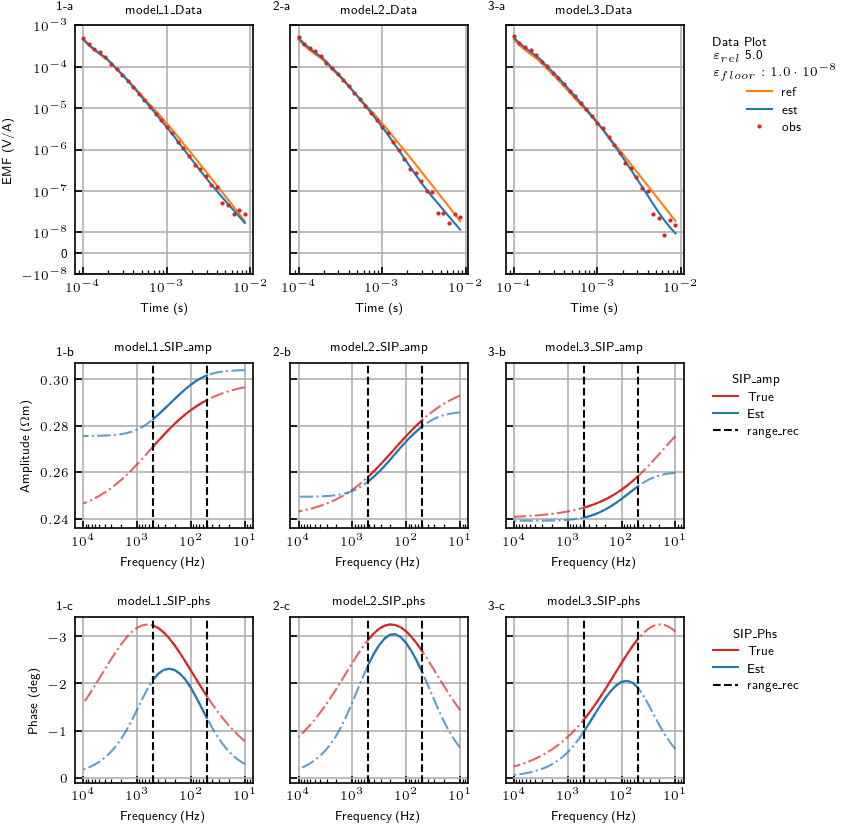

In [48]:
fig, ax = plt.subplots(3, nmodel,
        sharex='row', sharey='row', figsize=(textwidth,5.5), #  constrained_layout=True,  
    gridspec_kw={"width_ratios": [1.0, 1.0, 1],
                 "height_ratios": [1.5, 1.0, 1.0]
                }  # key line
    )
ax_ranges = []
for i in range(nmodel):
    ax_ranges.append([ax[0, i], ax[1, i], ax[2, i]])

for i in range(nmodel):
    dobs= dobs_cmb[i]
    mvec_obs = m_trues[i]
    title_head= title_heads[i]
    phid_itr = phid_itrs[i]
    model = models_rec_phid[i]
    freq = freq_cmb[i]
    nfreq = len(freq)
    ax_range = ax_ranges[i]
    axdata = ax_range[0]
    axsip = [ax_range[1], ax_range[2]]
    axdata = plot_data(
        data_init = dinit_refs[i],
        dpred=dpreds_phid[i],
        dobs=dobs,ax=axdata
        )
    sim = sim_sip_pel_ext[i]
    axsip = sim.plot_sip_model(model=mvec_obs, ax=axsip,
            color="C3", linestyle="-.", alpha=0.7)
    sim=sim_sip_dd_ext[i]
    # print(f"Model {i}: taus for ext sim: {sim.ip_model.taus}"   )
    axsip= sim.plot_sip_model(model=model, ax=axsip,
            color="C0", linestyle="-.", alpha=0.7 )
    
    if freq.shape[0] == 1:
        linestyle, marker, markersize = "", ".", 2.0
    else:
        linestyle, marker, markersize = "-", "", 1.0
    sim = sim_sip_pel[i]
    axsip = sim.plot_sip_model(model=mvec_obs, ax=axsip,
            color="C3", label=f"True", linestyle=linestyle,marker=marker,markersize=markersize)
    sim = sim_sip_dd[i]
    axsip = sim.plot_sip_model(model=model, ax=axsip,
            color="C0", label=f"Est", linestyle=linestyle, marker=marker, markersize=markersize)

    axsip[0].axvline(x=freq_mins[i], color='k', linestyle='--', linewidth=1.0,
                     label=f"range_rec"
                     )
    axsip[0].axvline(x=freq_maxs[i], color='k', linestyle='--', linewidth=1.0)
    axsip[1].axvline(x=freq_mins[i], color='k', linestyle='--', linewidth=1.0,
                     label=f"range_rec"
                     )
    axsip[1].axvline(x=freq_maxs[i], color='k', linestyle='--', linewidth=1.0)


    if i == (nmodel-1):
        title = (
            'Data Plot \n' +
            rf'$\varepsilon_{{rel}}$ {relative_error*100:.1f} %' + '\n' +
            rf'$\varepsilon_{{floor}}: {fmt(data_noise_floor,prec=1)} $'
        )
        axdata.legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
        title = 'SIP_amp'
        axsip[0].legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
        title = 'SIP_Phs'
        axsip[1].legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
        
    ax_range[0].set_title(f"{title_head}_Data")
    ax_range[1].set_title(f"{title_head}_SIP_amp")
    ax_range[2].set_title(f"{title_head}_SIP_phs")
    column_label = column_labels[i]
    low_names= ['-a', '-b', '-c']

    for label, axis in zip(low_names, ax_range):
        axis.text(
            -0.1, 1.1, f"{column_label}{label}",   # ✅ inside axes
             transform=axis.transAxes,
        fontweight="bold",
        va="top", ha="left"
    )

axsip[0].invert_xaxis()
axsip[1].invert_xaxis()
axsip[1].invert_yaxis()

for acol in ax[:, 1:nmodel]:
    for a in acol:
        a.tick_params(labelleft=False)
        a.set_ylabel("")
plt.savefig('../figures/46_DD_TEM_data_rec.png')
plt.savefig('../manuscript/figures/46_DD_TEM_data_rec.pdf')

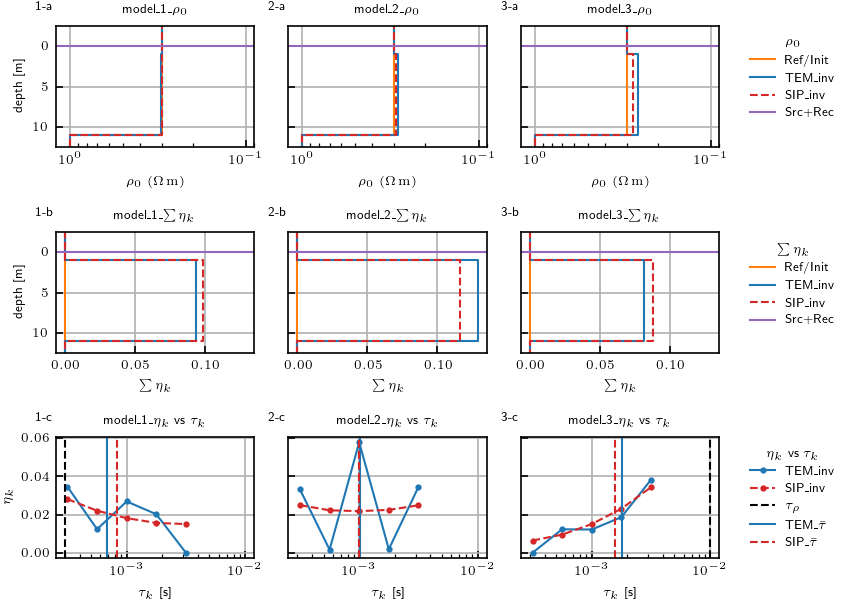

In [49]:
fig, ax = plt.subplots(
    3, nmodel, sharex='row', sharey='row',
    figsize=(textwidth ,4.0), #constrained_layout=True,  
    gridspec_kw={"width_ratios": [1.0, 1.0, 1],
                 "height_ratios": [1.0, 1.0, 1.0]
                }  # key line
)
ax_ranges = []
for i in range(nmodel):
    ax_ranges.append([ax[0, i], ax[1, i], ax[2, i]])
for i in range(nmodel):
    title_head = title_heads[i]
    ax_range = ax_ranges[i]
    axrm = ax_range[0:2]
    axetas = ax_range[2]

    m_ref = m_refs[i]

    taus = taus_act_cmb[i]
    tau_target = tau_targets[i]
    sim = sim_inv[i]
    linewidth = 1.0
    axrm = sim.plot_IP_par(mvec=m_ref, rm=True,
        label="Ref/Init", color=f"C1", linestyle="-",
        ax=axrm, linewidth=linewidth)
    axrm = sim.plot_IP_par(mvec=models_rec_phid[i], rm=True,
        label="TEM_inv", color=f"C0", linestyle="-", 
        ax=axrm, linewidth=linewidth)
    # rho0,eta = sim.ip_model.get_rho_eta(models_rec_phid[i])
    # label = fr"Est $\rho_0$:{rho0: .1e},$\eta$:{eta: .2f}"
    axrm = sim.plot_IP_par(mvec=sip_true_inv[i], rm=True,
            label="SIP_inv", color=f"C3", linestyle="--",
            ax=axrm, linewidth=linewidth)

    # rho0,eta = sim.ip_model.get_rho_eta(sip_true_inv[i])
    # label = fr"Rec $\rho_0$:{rho0: .1e},$\eta$:{eta: .2f}"
    sim= sim_sip_dd[i]

    axetas = sim.ip_model.plot_etas(models_rec_phid[i],
             ax=axetas, color="C0",
             label="TEM_inv",
            linestyle="-", marker='o', markersize=2.0
             )
    axetas = sim.ip_model.plot_etas(sip_true_inv[i],
             ax=axetas, color="C3", label="SIP_inv",
             linestyle="--", linewidth=linewidth,
             marker='o', markersize=2.0)
    axrm[0].invert_xaxis()
    axrm[0].set_xlim([1.2,0.09])

    axrm[0].set_title(fr"{title_head}_$\rho_0$")
    axrm[1].set_title(fr"{title_head}_$\sum\eta_k$")
    axetas.set_title(fr"{title_head}_$\eta_k$ vs $\tau_k$")
    label = fr"$\tau_\rho$" 
    linewidth_vline = 1.0
    axetas.axvline(x=tau_target, color='k', linestyle='--', linewidth=linewidth_vline,
                     label=label)
    label = r"TEM_$\bar{\tau}$" 
    axetas.axvline(x=tem_inv_taus[i], color='C0', linestyle='-', linewidth=linewidth_vline,
                     label=label)
    label = r"SIP_$\bar{\tau}$" 
    axetas.axvline(x=sip_true_inv_taus[i], color='C3', linestyle='--', linewidth=linewidth_vline,
                     label=label)

    for j , a in enumerate(axrm):  # Iterate over rows
        a.axhline(empymod_model_sim["src"][4], color=f"C4", linestyle="-", label="Src+Rec")
        a.set_ylim([12.5, -2.5])
        a.set_ylabel('depth [m]')
        if j== 0:
            a.set_xscale("log")
        else:
            a.set_xscale("linear")

    if i == nmodel-1:
        title=r"$\rho_0$"
        axrm[0].legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))
        title = r"$\sum\eta_k$"
        axrm[1].legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))
        title = r"$\eta_k$ vs $\tau_k$"
        axetas.legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))

    column_label = column_labels[i]

    for label, axis in zip(low_names, ax_range):
        axis.text(
            -0.1, 1.2, f"{column_label}{label}",   # ✅ inside axes
             transform=axis.transAxes,
        fontweight="bold",
        va="top", ha="left"
    )
for acol in ax[:, 1:nmodel]:
    for a in acol:
        a.tick_params(labelleft=False)
        a.set_ylabel("")

plt.savefig('../figures/46_Recovered_DD.png')
plt.savefig('../manuscript/figures/46_Recovered_DD.pdf')

In [50]:
ntau_print=[]
sip_inv_print=[]
tem_inv_print=[]
phid_print=[]
taurange_print = []
freqrange_print = []
for i in range(nmodel):
    taus_strt = taus_act_cmb[i].min() if taus_act_cmb[i].shape[0] > 0 else None
    taus_end = taus_act_cmb[i].max() if taus_act_cmb[i].shape[0] > 0 else None

    sip_inv_print.append(sip_true_inv[i])
    tem_inv_print.append(models_rec_phid[i])
    
    ntau_print.append(taus_act_cmb[i].shape[0])
    if taus_strt == taus_end:
        taurange_print.append(np.r_[taus_strt])
        freqrange_print.append(np.r_[freq_mins[i]])
    else:
        taurange_print.append(np.r_[taus_strt, taus_end])
        freqrange_print.append(np.r_[freq_mins[i], freq_maxs[i]])


In [51]:
rho0_print =[]
eta_print =[]
tau_print = []
c_print = []
for i in range(nmodel):
    rho0_print.append(rho0_targets[i])
    eta_print.append(eta_targets[i])
    tau_print.append(tau_targets[i])
    c_print.append(c_targets[i])

    model = np.array(tem_inv_print[i])
    rho0 = np.exp(model[0])
    eta = model[1:].sum()
    rho0_print.append(rho0)
    eta_print.append(eta)
    tau_print.append(tem_inv_taus[i])
    c_print.append("")
    
    model = np.array(sip_inv_print[i])
    rho0 = np.exp(model[0])
    eta = model[1:].sum() 
    rho0_print.append(rho0)
    eta_print.append(eta)
    tau_print.append(sip_true_inv_taus[i])
    c_print.append("")
names_print=[]
for i in range(nmodel):
    names_print.append(f"True")
    names_print.append(f"TEM inv")
    names_print.append(f"SIP inv")
titles_print=[]
for i in range(nmodel):
    titles_print.append(f"model {i+1}")

In [53]:

taurange = taurange_print[0]
freqrange = freqrange_print[0]
print(
    r"\multicolumn{10}{c|}{"
    + rf"$\tau_k$ band: \num{{{taurange[0]:.1e}}}"
    + rf" to \num{{{taurange[1]:.1e}}}, "
    + rf" n: \num{{{ntau_print[0]:.0f}}}, "
    + rf" Frequency band: \num{{{freq_mins[0]:.1e}}}"
    + rf" to \num{{{freq_maxs[0]:.1e}}}"
    + r"} \\"
)
print(r"\hline")

print(r" & \multicolumn{3}{c|}{"
      + r"} & \multicolumn{3}{c|}{".join(f"{v}" for v in titles_print
                                         )
       + r"} \\"
)

print("\hline")
print("   & "
      +" & ".join(f"{v}" for v in names_print
      )
       + r" \\"
)

print("\hline")
print(r"$\rho_0$ (\si{\Omega \meter}) & \num{"
      +r"} & \num{".join(f"{v:4.2f}" for v in  rho0_print)
       + r"} \\"
)
print(r"$\eta$ & \num{"
      +r"} & \num{".join(f"{v:4.2f}" for v in eta_print)
     + r"} \\"
)
print(r"$\tau$ (\si{\second}) & \num{"
      +r"} & \num{".join(f"{v:.1e}" for v in tau_print)
     + r"} \\"
)
# print(
#     r"C & "
#     + r"\num{0.6} & & & "
#     + r"\num{0.6} & & & "
#     + r"\num{0.6} & & \\"
# )

\multicolumn{10}{c|}{$\tau_k$ band: \num{3.2e-04} to \num{3.2e-03},  n: \num{5},  Frequency band: \num{5.0e+01} to \num{5.0e+02}} \\
\hline
 & \multicolumn{3}{c|}{model 1} & \multicolumn{3}{c|}{model 2} & \multicolumn{3}{c|}{model 3} \\
\hline
   & True & TEM inv & SIP inv & True & TEM inv & SIP inv & True & TEM inv & SIP inv \\
\hline
$\rho_0$ (\si{\Omega \meter}) & \num{0.30} & \num{0.30} & \num{0.30} & \num{0.30} & \num{0.29} & \num{0.29} & \num{0.30} & \num{0.26} & \num{0.28} \\
$\eta$ & \num{0.20} & \num{0.09} & \num{0.10} & \num{0.20} & \num{0.13} & \num{0.12} & \num{0.20} & \num{0.08} & \num{0.09} \\
$\tau$ (\si{\second}) & \num{3.0e-04} & \num{6.9e-04} & \num{8.3e-04} & \num{1.0e-03} & \num{1.0e-03} & \num{1.0e-03} & \num{1.0e-02} & \num{1.8e-03} & \num{1.6e-03} \\
